In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
import numpy as np
import cv2
import os
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import xml.etree.ElementTree as ET
from pathlib import Path
import re

In [8]:
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU доступен: {tf.config.list_physical_devices('GPU')}")
np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
GPU доступен: []


In [9]:
class Config:
    # Пути к данным
    DATA_ROOT = "plates"
    
    # Подпапки с данными
    TRAIN_PATH = os.path.join(DATA_ROOT, "train")
    VAL_PATH = os.path.join(DATA_ROOT, "val")
    TEST_PATH = os.path.join(DATA_ROOT, "test")
    
    # Пути для сохранения модели
    MODEL_SAVE_DIR = "models/recognition"
    MODEL_NAME = "crnn_plate.h5"
    CHAR_SET_PATH = os.path.join(MODEL_SAVE_DIR, "char_set.json")
    MODEL_CONFIG_PATH = os.path.join(MODEL_SAVE_DIR, "model_config.json")
    
    # Параметры модели
    IMG_HEIGHT = 64
    IMG_WIDTH = 200
    BATCH_SIZE = 32
    EPOCHS = 100
    LEARNING_RATE = 0.001
    VALIDATION_SPLIT = 0.1
    
    # Максимальная длина номера
    MAX_PLATE_LENGTH = 12  #"А123ВС777"
    
    # Параметры предобработки
    USE_AUGMENTATION = True
    AUGMENTATION_PROB = 0.5

config = Config()

# Создаем папку для сохранения модели
os.makedirs(config.MODEL_SAVE_DIR, exist_ok=True)

def parse_voc_annotation(ann_path):
    """
    Парсит XML файл в формате VOC и извлекает текст номера
    Предполагается, что текст номера находится в теге <name>
    """
    try:
        tree = ET.parse(ann_path)
        root = tree.getroot()

        for obj in root.findall('object'):
            name = obj.find('name')
            if name is not None and name.text:

                plate_text = name.text.strip().upper()

                plate_text = re.sub(r'[\s\-]', '', plate_text)
                if plate_text:
                    return plate_text
        
        # Вариант 2: номер в <plate> или другом теге (адаптируйте под ваш формат)
        #plate = root.find('plate')
        #if plate is not None and plate.text:
        #    return plate.text.strip().upper()
        
        #return None
        
    except Exception as e:
        print(f"Ошибка при парсинге {ann_path}: {e}")
        return None

def load_dataset(data_path):

    img_dir = os.path.join(data_path, "img")
    ann_dir = os.path.join(data_path, "ann")

    images = []
    labels = []
    skipped = 0

    json_files = [f for f in os.listdir(ann_dir) if f.endswith(".json")]

    print(f"Загрузка из {data_path}: найдено {len(json_files)} аннотаций")

    for json_file in json_files:

        json_path = os.path.join(ann_dir, json_file)

        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)

            plate_text = data.get("description", "").strip().upper()

            if not plate_text:
                skipped += 1
                continue

            # имя изображения
            img_name = data.get("name", json_file.replace(".json", ""))

            img_path = None
            for ext in ['.jpg', '.png', '.jpeg']:
                candidate = os.path.join(img_dir, img_name + ext)
                if os.path.exists(candidate):
                    img_path = candidate
                    break

            if img_path is None:
                skipped += 1
                continue

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            if img is None:
                skipped += 1
                continue

            img = cv2.resize(img, (config.IMG_WIDTH, config.IMG_HEIGHT))
            img = img.astype(np.float32) / 255.0

            images.append(img)
            labels.append(plate_text)

        except Exception as e:
            print(f"Ошибка: {json_file} -> {e}")
            skipped += 1

    print(f"Загружено: {len(images)}, пропущено: {skipped}")

    return np.array(images), labels

In [10]:
# Загружаем данные
train_images, train_labels = load_dataset(config.TRAIN_PATH)
val_images, val_labels = load_dataset(config.VAL_PATH)
test_images, test_labels = load_dataset(config.TEST_PATH)

print(f"\nTrain: {len(train_images)}")
print(f"Val: {len(val_images)}")
print(f"Test: {len(test_images)}")

# Примеры загруженных данных
print(f"\nПримеры номеров:")
for i in range(min(5, len(train_labels))):
    print(f"  {train_labels[i]}")

Загрузка из plates\train: найдено 49382 аннотаций


KeyboardInterrupt: 

In [ ]:
# 4. Создание словаря символов

def build_char_set(labels):
    """
    Создает словарь символов из всех меток
    """
    chars = set()
    for label in labels:
        for char in label:
            chars.add(char)
    
    chars = sorted(list(chars))
    
    char_to_idx = {char: idx + 1 for idx, char in enumerate(chars)}
    
    char_to_idx['[BLANK]'] = 0

    idx_to_char = {idx: char for char, idx in char_to_idx.items()}
    
    return char_to_idx, idx_to_char, len(chars) + 1

Всего символов (включая blank): 1
Символы: ['[BLANK]']
Словарь сохранен в models/recognition\char_set.json


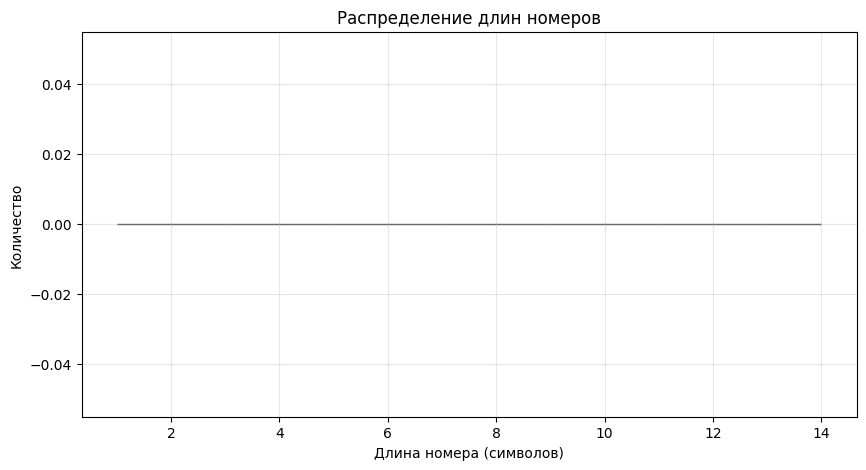

c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3824: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Средняя длина: nan


ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
# Создаем словарь на основе всех данных
all_labels = train_labels + val_labels + test_labels
char_to_idx, idx_to_char, num_classes = build_char_set(all_labels)

print(f"Всего символов (включая blank): {num_classes}")
print(f"Символы: {list(char_to_idx.keys())}")

# Сохраняем словарь
with open(config.CHAR_SET_PATH, 'w', encoding='utf-8') as f:
    json.dump(char_to_idx, f, ensure_ascii=False, indent=2)
print(f"Словарь сохранен в {config.CHAR_SET_PATH}")

# %%
# Визуализируем распределение длин номеров
plate_lengths = [len(label) for label in all_labels]
plt.figure(figsize=(10, 5))
plt.hist(plate_lengths, bins=range(1, 15), alpha=0.7, edgecolor='black')
plt.xlabel('Длина номера (символов)')
plt.ylabel('Количество')
plt.title('Распределение длин номеров')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Средняя длина: {np.mean(plate_lengths):.1f}")
print(f"Максимальная длина: {np.max(plate_lengths)}")

In [ ]:
# ## 5. Генератор данных для CTC

# %%
def encode_text(text, char_to_idx, max_length):
    """
    Преобразует текст в последовательность индексов для CTC
    """
    encoded = [char_to_idx[char] for char in text if char in char_to_idx]
    return encoded

def ctc_data_generator(images, labels, char_to_idx, batch_size, max_label_length, is_training=True):
    """
    Генератор данных для обучения с CTC loss
    """
    num_samples = len(images)
    indices = np.arange(num_samples)
    
    # Выходная длина после CNN (ширина уменьшается в 4 раза из-за MaxPooling)
    output_width = config.IMG_WIDTH // 4  # 200 // 4 = 50
    
    while True:
        if is_training:
            np.random.shuffle(indices)
        
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch_indices = indices[start:end]
            
            batch_images = []
            batch_labels = []
            batch_label_lengths = []
            
            for idx in batch_indices:
                img = images[idx]
                text = labels[idx]
                
                # Добавляем размерность канала
                batch_images.append(np.expand_dims(img, axis=-1))
                
                # Кодируем текст
                encoded = encode_text(text, char_to_idx, max_label_length)
                batch_labels.append(encoded)
                batch_label_lengths.append(len(encoded))
            
            # Паддинг для меток
            max_len = max(len(lbl) for lbl in batch_labels)
            padded_labels = np.zeros((len(batch_images), max_len), dtype=np.int32)
            for i, lbl in enumerate(batch_labels):
                padded_labels[i, :len(lbl)] = lbl
            
            # Создаем входные данные для CTC loss
            # tf.nn.ctc_loss ожидает: labels, logits, label_length, logit_length
            input_length = np.full((len(batch_images), 1), output_width, dtype=np.int32)
            label_length = np.array(batch_label_lengths, dtype=np.int32).reshape(-1, 1)
            
            # Объединяем метки и длины для передачи через fit
            # В Keras 2.x удобнее использовать custom training loop
            yield batch_images, padded_labels, input_length, label_length

In [ ]:
# 6. Построение CRNN модели

def build_crnn(input_shape, num_classes, output_width):
    """
    Строит CRNN модель для распознавания текста с CTC loss
    """
    inputs = layers.Input(shape=input_shape, name='input')
    
    # CNN часть
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv1')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), name='pool1')(x)
    
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu', name='conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2), name='pool2')(x)
    
    x = layers.Conv2D(256, (3, 3), padding='same', activation='relu', name='conv3')(x)
    x = layers.BatchNormalization()(x)
    
    # Преобразование для RNN: (batch, height, width, channels) -> (batch, time_steps, features)
    # После двух MaxPooling: height = 64 -> 16, width = 200 -> 50
    new_shape = x.shape
    time_steps = new_shape[1]  # height
    features = new_shape[2] * new_shape[3]  # width * channels
    
    x = layers.Reshape((time_steps, features), name='reshape')(x)
    
    # RNN часть
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.2), name='lstm1')(x)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=0.2), name='lstm2')(x)
    
    # Выходной слой
    # num_classes + 1 для blank символа в CTC
    outputs = layers.Dense(num_classes + 1, activation='softmax', name='output')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Параметры модели
input_shape = (config.IMG_HEIGHT, config.IMG_WIDTH, 1)
output_width = config.IMG_WIDTH // 4  # после двух MaxPooling: 200/2/2 = 50

# Строим модель
model = build_crnn(input_shape, num_classes, output_width)
model.summary()

In [ ]:
# ## 7. Функция CTC loss

class CTCLayer(layers.Layer):
    """
    Слой для вычисления CTC loss
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
    
    def call(self, inputs):
        y_pred, labels, input_length, label_length = inputs
        
        loss = tf.nn.ctc_loss(
            labels=labels,
            logits=y_pred,
            label_length=label_length,
            logit_length=input_length,
            logits_time_major=False
        )
        
        self.add_loss(tf.reduce_mean(loss))
        
        return y_pred

def build_ctc_model(base_model, num_classes):
    """
    Оборачивает CRNN модель в модель с CTC loss
    """
    # Входы
    input_img = base_model.input
    labels = layers.Input(shape=(None,), dtype='int32', name='labels')
    input_length = layers.Input(shape=(1,), dtype='int32', name='input_length')
    label_length = layers.Input(shape=(1,), dtype='int32', name='label_length')
    
    # Получаем предсказания
    y_pred = base_model.output
    
    # Добавляем CTC слой
    loss_out = CTCLayer()([y_pred, labels, input_length, label_length])
    
    # Создаем модель для обучения
    ctc_model = Model(
        inputs=[input_img, labels, input_length, label_length],
        outputs=loss_out
    )
    
    return ctc_model

# %%
# Создаем модель с CTC loss
ctc_model = build_ctc_model(model, num_classes)

# Компилируем
ctc_model.compile(optimizer=keras.optimizers.Adam(learning_rate=config.LEARNING_RATE))

print("Модель с CTC loss скомпилирована")

In [ ]:
# %% [markdown]
# ## 8. Подготовка данных для обучения

# %%
def prepare_data_for_ctc(images, labels, char_to_idx, max_label_length):
    """
    Подготавливает данные для обучения с CTC
    """
    batch_images = []
    batch_labels = []
    batch_label_lengths = []
    
    output_width = config.IMG_WIDTH // 4
    
    for img, text in zip(images, labels):
        batch_images.append(np.expand_dims(img, axis=-1))
        
        encoded = encode_text(text, char_to_idx, max_label_length)
        batch_labels.append(encoded)
        batch_label_lengths.append(len(encoded))
    
    # Паддинг меток
    max_len = max(len(lbl) for lbl in batch_labels)
    padded_labels = np.zeros((len(batch_labels), max_len), dtype=np.int32)
    for i, lbl in enumerate(batch_labels):
        padded_labels[i, :len(lbl)] = lbl
    
    input_length = np.full((len(images), 1), output_width, dtype=np.int32)
    label_length = np.array(batch_label_lengths, dtype=np.int32).reshape(-1, 1)
    
    return batch_images, padded_labels, input_length, label_length

# %%
# Подготавливаем данные
print("Подготовка данных для обучения...")

train_images_list = [img for img in train_images]
train_data = prepare_data_for_ctc(train_images_list, train_labels, char_to_idx, config.MAX_PLATE_LENGTH)

val_images_list = [img for img in val_images]
val_data = prepare_data_for_ctc(val_images_list, val_labels, char_to_idx, config.MAX_PLATE_LENGTH)

print(f"Train: {len(train_images_list)}")
print(f"Val: {len(val_images_list)}")

In [ ]:
# ## 9. Обучение модели

# %%
# Создаем колбэки
callbacks = [
    keras.callbacks.ModelCheckpoint(
        os.path.join(config.MODEL_SAVE_DIR, config.MODEL_NAME),
        monitor='val_loss',
        save_best_only=True,
        mode='min',
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        verbose=1,
        min_lr=1e-6
    ),
    keras.callbacks.TensorBoard(
        log_dir='logs/recognition',
        histogram_freq=1
    )
]

# %%
# Обучение
print("Начало обучения...")
print("="*50)

history = ctc_model.fit(
    x={
        'input': np.array(train_images_list),
        'labels': train_data[1],
        'input_length': train_data[2],
        'label_length': train_data[3]
    },
    y=None,
    batch_size=config.BATCH_SIZE,
    epochs=config.EPOCHS,
    validation_data=(
        {
            'input': np.array(val_images_list),
            'labels': val_data[1],
            'input_length': val_data[2],
            'label_length': val_data[3]
        },
        None
    ),
    callbacks=callbacks,
    verbose=1
)


In [ ]:
# Сохраняем историю обучения
with open(os.path.join(config.MODEL_SAVE_DIR, 'training_history.json'), 'w') as f:
    json.dump(history.history, f)

# %% [markdown]
# ## 10. Визуализация обучения

# %%
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Learning Rate (если изменился)
    if 'lr' in history.history:
        axes[1].plot(history.history['lr'], label='Learning Rate')
        axes[1].set_title('Learning Rate')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('LR')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [ ]:
# ## 11. Функция для инференса

# %%
def decode_ctc_output(y_pred, idx_to_char):
    """
    Декодирует выход CTC в текст
    """
    # Получаем индексы с максимальной вероятностью
    pred_indices = np.argmax(y_pred, axis=2)[0]
    
    # Убираем повторы и blank
    prev = -1
    result = []
    for idx in pred_indices:
        if idx != prev and idx != 0:  # 0 - blank символ
            if idx in idx_to_char:
                result.append(idx_to_char[idx])
        prev = idx
    
    return ''.join(result)

def recognize_plate(model, plate_image, idx_to_char, img_height=64, img_width=200):
    """
    Распознает номер на изображении
    """
    # Предобработка
    if len(plate_image.shape) == 3:
        plate_image = cv2.cvtColor(plate_image, cv2.COLOR_BGR2GRAY)
    
    img = cv2.resize(plate_image, (img_width, img_height))
    img = img.astype(np.float32) / 255.0
    img = np.expand_dims(img, axis=(0, -1))  # (1, height, width, 1)
    
    # Инференс
    predictions = model.predict(img, verbose=0)
    
    # Декодирование
    text = decode_ctc_output(predictions, idx_to_char)
    
    return text

# Загружаем лучшую модель для инференса
best_model = keras.models.load_model(
    os.path.join(config.MODEL_SAVE_DIR, config.MODEL_NAME),
    custom_objects={'CTCLayer': CTCLayer}
)

In [ ]:
# ## 12. Тестирование на валидационных данных

# %%
def test_model(model, images, labels, idx_to_char, num_samples=10):
    """
    Тестирует модель на случайных примерах
    """
    indices = np.random.choice(len(images), min(num_samples, len(images)), replace=False)
    
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    
    correct = 0
    for i, idx in enumerate(indices):
        img = images[idx]
        true_label = labels[idx]
        
        # Распознаем
        pred_label = recognize_plate(model, img, idx_to_char)
        
        # Отображаем
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=10)
        axes[i].axis('off')
        
        if pred_label == true_label:
            correct += 1
            axes[i].set_title(f"✅ {true_label}\n{pred_label}", fontsize=10)
        else:
            axes[i].set_title(f"❌ True: {true_label}\nPred: {pred_label}", fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Точность на {len(indices)} примерах: {correct/len(indices)*100:.1f}%")

# Тестируем
test_model(best_model, val_images, val_labels, idx_to_char, num_samples=10)

In [ ]:
# ## 13. Оценка на тестовом датасете

# %%
def evaluate_model(model, images, labels, idx_to_char):
    """
    Полная оценка модели на всем датасете
    """
    correct = 0
    total = len(images)
    results = []
    
    print(f"Оценка на {total} изображениях...")
    
    for img, true_label in tqdm(zip(images, labels), total=total):
        pred_label = recognize_plate(model, img, idx_to_char)
        results.append({
            'true': true_label,
            'pred': pred_label,
            'correct': pred_label == true_label
        })
        
        if pred_label == true_label:
            correct += 1
    
    accuracy = correct / total * 100
    print(f"\nТочность: {accuracy:.2f}% ({correct}/{total})")
    
    # Выводим ошибки
    errors = [r for r in results if not r['correct']]
    if errors:
        print(f"\nОшибки ({len(errors)}):")
        for err in errors[:20]:
            print(f"  True: {err['true']} -> Pred: {err['pred']}")
    
    return results, accuracy

# Оцениваем на тестовых данных
test_results, test_accuracy = evaluate_model(best_model, test_images, test_labels, idx_to_char)

# %% [markdown]
# ## 14. Сохранение дополнительных файлов

# %%
# Сохраняем конфигурацию модели
model_config = {
    'input_height': config.IMG_HEIGHT,
    'input_width': config.IMG_WIDTH,
    'num_classes': num_classes,
    'output_width': config.IMG_WIDTH // 4,
    'max_plate_length': config.MAX_PLATE_LENGTH,
    'test_accuracy': test_accuracy
}

with open(config.MODEL_CONFIG_PATH, 'w', encoding='utf-8') as f:
    json.dump(model_config, f, ensure_ascii=False, indent=2)

print(f"Конфигурация сохранена в {config.MODEL_CONFIG_PATH}")

# %%
# Сохраняем модель в формате .h5 (уже сохранена через ModelCheckpoint)
print(f"\n✅ Модель сохранена в {os.path.join(config.MODEL_SAVE_DIR, config.MODEL_NAME)}")
print(f"✅ Словарь сохранен в {config.CHAR_SET_PATH}")

# %% [markdown]
# ## 15. Пример использования обученной модели

# %%
def load_trained_model(model_path, char_set_path):
    """
    Загружает обученную модель и словарь
    """
    # Загружаем словарь
    with open(char_set_path, 'r', encoding='utf-8') as f:
        char_to_idx = json.load(f)
    
    # Создаем обратное отображение
    idx_to_char = {int(idx): char for char, idx in char_to_idx.items()}
    
    # Загружаем модель
    model = keras.models.load_model(
        model_path,
        custom_objects={'CTCLayer': CTCLayer}
    )
    
    return model, idx_to_char

# Пример использования
model, idx_to_char = load_trained_model(
    os.path.join(config.MODEL_SAVE_DIR, config.MODEL_NAME),
    config.CHAR_SET_PATH
)

# Распознаем номер на случайном изображении
sample_img = test_images[0]
sample_true = test_labels[0]
sample_pred = recognize_plate(model, sample_img, idx_to_char)

plt.figure(figsize=(6, 3))
plt.imshow(sample_img, cmap='gray')
plt.title(f"True: {sample_true} | Pred: {sample_pred}", fontsize=14)
plt.axis('off')
plt.show()

print("\n✅ Обучение завершено! Модель готова к использованию в ANPR пайплайне.")